In [2]:
import tensorflow as tf
from tensorflow import keras
from keras.utils import image_dataset_from_directory
from keras import Sequential,layers
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten,Dropout,GlobalAveragePooling2D

In [ ]:
## generators
train_ds=image_dataset_from_directory(
    directory=r'nsfw_project_dataset\train',
    labels='inferred',
    label_mode='int',
    batch_size=40,
    image_size=(214,214),
)

validation_ds=image_dataset_from_directory(
    directory=r'nsfw_project_dataset\val',
    labels='inferred',
    label_mode='int',
    batch_size=40,
    image_size=(214,214)
)

Found 17920 files belonging to 2 classes.
Found 4480 files belonging to 2 classes.


In [3]:
## got np array whose values in (0,255) we need (0,1)
## normalization

def process(image,label):
    image=tf.cast(image/255,tf.float32)
    return image,label

train_ds=train_ds.map(process)
validation_ds=validation_ds.map(process)

In [4]:
### create CNN model
def NSFW_model_training():
    model=Sequential()

    model.add(layers.RandomFlip('horizontal',input_shape=(214,214,3)))
    model.add(layers.RandomRotation(0.1))
    model.add(layers.RandomZoom(0.1))
    model.add(layers.RandomContrast(0.1))
    model.add(layers.RandomCrop(height=180,width=180))

    model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu'))
    model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

    model.add(Conv2D(54,kernel_size=(3,3),padding='valid',activation='relu'))
    model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

    model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'))
    model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

    model.add(GlobalAveragePooling2D())

    model.add(Dense(128,activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(64,activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(1,activation='sigmoid'))

    return model

model=NSFW_model_training()

d:\Udemy\NSFW detection\venv\lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [5]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 214, 214, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 214, 214, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 214, 214, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ (None, 214, 214, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_crop (RandomCrop)        │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 87, 87, 54)     │        15,606 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 43, 43, 54)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 41, 41, 128)    │        62,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 103,671 (404.96 KB)

 Trainable params: 103,671 (404.96 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy',keras.metrics.FalseNegatives()])

In [7]:
history=model.fit(train_ds,epochs=10,validation_data=validation_ds)

Epoch 1/10
448/448 ━━━━━━━━━━━━━━━━━━━━ 540s 1s/step - accuracy: 0.7212 - false_negatives: 2708.0000 - loss: 0.5494 - val_accuracy: 0.7556 - val_false_negatives: 733.0000 - val_loss: 0.5023
Epoch 2/10
448/448 ━━━━━━━━━━━━━━━━━━━━ 472s 1s/step - accuracy: 0.7751 - false_negatives: 2061.0000 - loss: 0.4839 - val_accuracy: 0.7913 - val_false_negatives: 376.0000 - val_loss: 0.4716
Epoch 3/10
448/448 ━━━━━━━━━━━━━━━━━━━━ 482s 1s/step - accuracy: 0.7812 - false_negatives: 1924.0000 - loss: 0.4729 - val_accuracy: 0.7967 - val_false_negatives: 402.0000 - val_loss: 0.4541
Epoch 4/10
448/448 ━━━━━━━━━━━━━━━━━━━━ 476s 1s/step - accuracy: 0.7918 - false_negatives: 1763.0000 - loss: 0.4603 - val_accuracy: 0.8038 - val_false_negatives: 413.0000 - val_loss: 0.4458
Epoch 5/10
448/448 ━━━━━━━━━━━━━━━━━━━━ 468s 1s/step - accuracy: 0.7985 - false_negatives: 1669.0000 - loss: 0.4441 - val_accuracy: 0.8016 - val_false_negatives: 297.0000 - val_loss: 0.4539
Epoch 6/10
448/448 ━━━━━━━━━━━━━━━━━━━━ 470s 1s/st

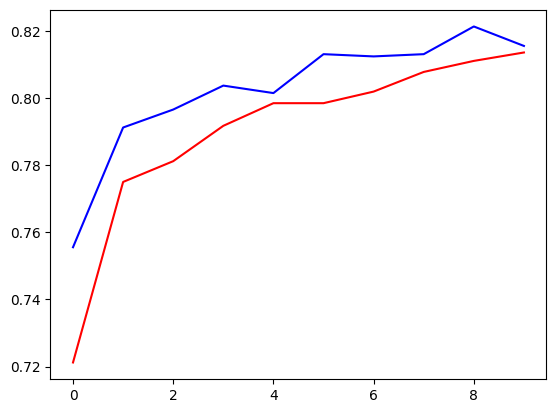

In [12]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='training')
plt.plot(history.history['val_accuracy'],color='blue',label='testing')
plt.show()

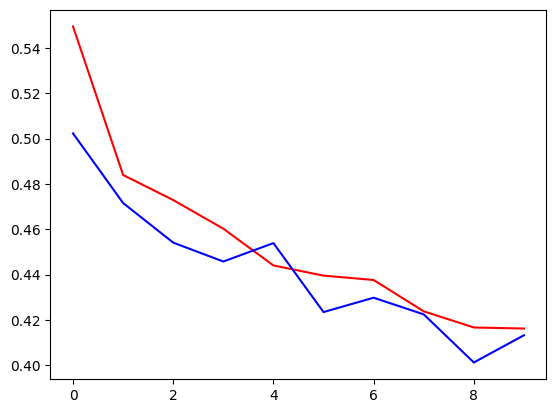

In [13]:
plt.plot(history.history['loss'],color='red',label='training')
plt.plot(history.history['val_loss'],color='blue',label='testing')
plt.show()

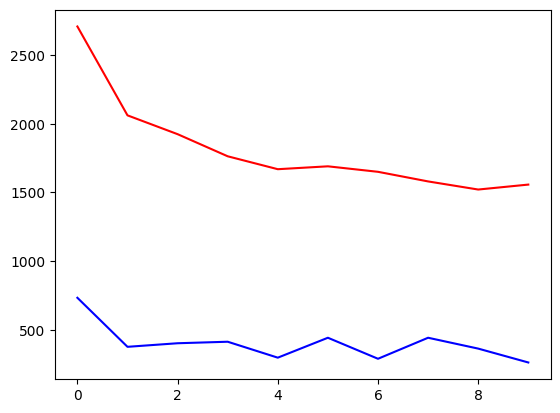

In [14]:
plt.plot(history.history['false_negatives'],color='red',label='training')
plt.plot(history.history['val_false_negatives'],color='blue',label='testing')
plt.show()

In [19]:
import numpy as np
avg_accuracy=np.average(history.history['accuracy'])
avg_val_accuracy=np.average(history.history['val_accuracy'])

In [20]:
avg_FN=np.average(history.history['false_negatives'])
avg_val_FN=np.average(history.history['val_false_negatives'])

In [21]:
print(f'avg_accuracy:{avg_accuracy} and avg_val_accuracy:{avg_val_accuracy}')
print(f'avg_FN:{avg_FN} and avg_val_FN:{avg_val_FN}')

avg_accuracy:0.7901116132736206 and avg_val_accuracy:0.8024776816368103
avg_FN:1812.3 and avg_val_FN:401.9


In [24]:
model.save(r'models\NSFW_predictor.keras')